# Sentinel-X — Maintenance prédictive (Isolation Forest)

Ce notebook raconte la démarche ; **tout le code vit dans le package `sentinel_pm`** (`src/sentinel_pm/`).
Pour modifier un calcul, on modifie le package (et ses tests), jamais ce notebook.

Prérequis : `pip install -e ".[notebook]"` depuis `predictive_maintenance/`.

In [ ]:
from dataclasses import replace
import json

import matplotlib.pyplot as plt
import pandas as pd

from sentinel_pm import load_config, make_features, train_detector, detect, save_bundle, load_bundle, RealTimeDetector
from sentinel_pm.data import build_dataset
from sentinel_pm.evaluation import point_metrics, event_report, false_alarm_breakdown
from sentinel_pm import visualization as viz

cfg = load_config("../configs/default.yaml")
fc = cfg.features
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

: 

### Étape 1 — Simulation des données capteurs

On imagine l'ESP8266 qui envoie **1 mesure par minute** (dans le vrai projet ce sera plutôt toutes les 2 à 10 secondes ; le DHT22 ne peut pas être lu plus vite qu'environ toutes les 2 s).

**Capteurs simulés :**
- `temperature` (°C) et `humidity` (%) — DHT22 : cycle jour/nuit + bruit ;
- `gas` — MQ-2, valeur brute du convertisseur analogique (0–1023) ;
- `pir` — détecteur de présence (0/1), généré mais **non utilisé** par ce modèle (il servira plutôt à la partie vision / corrélation).

**Pannes injectées (uniquement dans la période de test) :**

| Événement | Description | Pourquoi c'est intéressant |
|---|---|---|
| `slow_drift` | Température et gaz montent **lentement et ensemble** | C'est l'exemple du sujet : prédire l'incident *avant* le seuil critique |
| `gas_spike` | Pic brutal de gaz puis retombée | Fuite de gaz |
| `overheating` | Montée rapide de la température | Surchauffe thermique |
| `frozen_sensor` | Le DHT22 renvoie toujours la même valeur | Panne de capteur : aucune valeur n'est « trop haute », un `if` ne la voit pas ! |

Les paramètres (durées, pannes injectées, seed) sont dans `configs/default.yaml`.

In [2]:
data, train, test = build_dataset(cfg.simulation, cfg.seed)

print(f"Train : {len(train)} mesures | anomalies : {train['label'].sum()}")
print(f"Test  : {len(test)} mesures | anomalies : {test['label'].sum()} ({test['label'].mean():.1%})")
data.head()

Train : 5760 mesures | anomalies : 0
Test  : 2880 mesures | anomalies : 555 (19.3%)


,temperature,humidity,gas,pir,label,event
timestamp,,,,,,
2026-10-05 08:00:00,21.071375,57.434811,183.447686,0,0,normal
2026-10-05 08:01:00,20.774480,59.068109,167.283575,0,0,normal
2026-10-05 08:02:00,21.059808,55.252526,164.955066,0,0,normal
2026-10-05 08:03:00,21.219578,53.183658,180.442210,0,0,normal
2026-10-05 08:04:00,20.778670,57.214576,178.607496,0,0,normal


> ⚠️ **Point méthodologique important — découpe temporelle**
> Sur une série temporelle, on **ne mélange jamais** les lignes (`shuffle`) : on entraîne sur le passé et on teste sur le futur, comme en conditions réelles.
> Ici le modèle sera entraîné sur 4 jours **sans panne** (la « période de calibration » où le boîtier fonctionne normalement) — c'est exactement ce que tu pourras faire avec la vraie ESP8266 : laisser tourner le boîtier quelques heures au calme, puis s'en servir comme référence du « normal ».

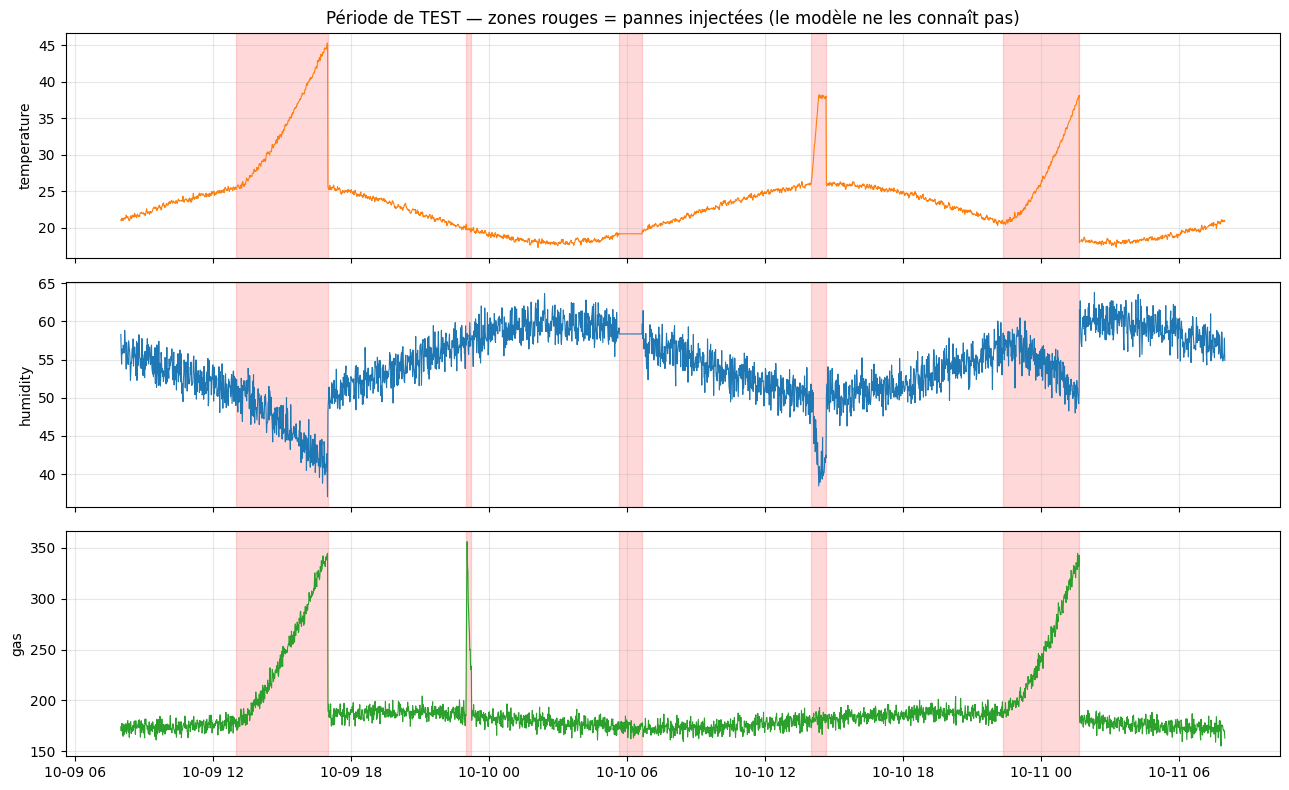

In [3]:
viz.plot_sensors(test, "Période de TEST — zones rouges = pannes injectées (le modèle ne les connaît pas)");

**Observations :**
- La **dérive lente** (1er et 5e événement) est quasiment invisible au début : température et gaz restent dans les valeurs « normales » pendant un long moment. Un seuil fixe ne réagit qu'à la fin, quand c'est presque trop tard.
- Le **capteur figé** ne dépasse aucune valeur limite : la température reste plausible, c'est son **absence de variation** qui est anormale.
- Le **pic de gaz** et la **surchauffe** sont plus évidents.

Il faut donc regarder **la dynamique** (pente, variabilité, corrélation) et pas seulement la valeur instantanée. C'est le rôle du feature engineering.

### Étape 3 — Feature engineering (créer des variables « cinétiques »)

Un modèle ne comprend pas le « temps » : on lui donne une **photo à l'instant t**. Pour qu'il perçoive la dynamique, on résume la fenêtre récente de chaque capteur :

| Feature | Formule | Ce qu'elle détecte |
|---|---|---|
| `temperature`, `humidity`, `gas` | valeur brute | Valeurs hors plage |
| `temp_slope`, `gas_slope` | (x(t) − x(t−30)) / 30 | **Dérive lente** (montée régulière) |
| `temp_std`, `hum_std`, `gas_std` | écart-type sur 15 min (en échelle log pour T° et humidité) | **Capteur figé** (variabilité ≈ 0) ou instable |
| `temp_amp`, `hum_amp`, `gas_amp` | max − min sur 15 min (en échelle log) | Même idée, vue complémentaire : une amplitude nulle = signal plat |
| `corr_temp_gas` | corrélation T°/gaz sur 30 min | **Les deux montent ensemble** (exemple du sujet) |

> Implémentation : `sentinel_pm.features.make_features` — utilisée **à l'identique** à l'entraînement et en temps réel.

In [4]:
X_train = make_features(train, fc.window, fc.window_long)
X_test  = make_features(test, fc.window, fc.window_long)
y_test  = test.loc[X_test.index, "label"]

print("X_train :", X_train.shape, "| X_test :", X_test.shape)
X_train.describe().T[["mean", "std", "min", "max"]].round(3)

X_train : (5730, 12) | X_test : (2850, 12)


,mean,std,min,max
temperature,21.999,2.833,17.523,26.717
humidity,54.971,3.727,45.685,64.579
gas,180.178,7.491,157.235,202.815
temp_slope,-0.000,0.016,-0.050,0.052
gas_slope,-0.000,0.239,-0.884,0.902
temp_std,-0.723,0.103,-1.182,-0.421
hum_std,0.170,0.087,-0.163,0.418
gas_std,4.908,0.914,2.270,8.397
temp_amp,-0.187,0.106,-0.655,0.110
hum_amp,0.719,0.096,0.326,0.941


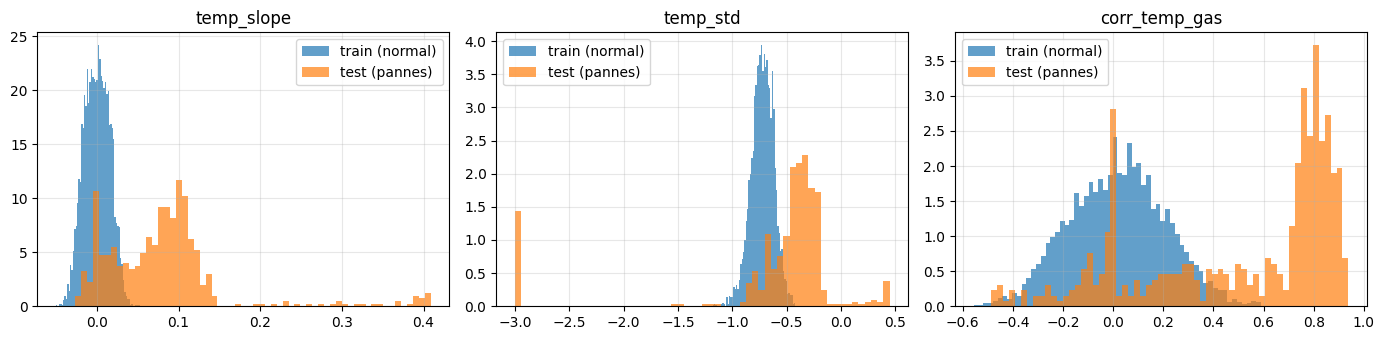

In [5]:
viz.plot_feature_distributions(X_train, X_test, y_test);

>**Leçon apprise en construisant ce notebook** : avec seulement `temp_std` et `hum_std`, l'Isolation Forest *ratait* le capteur figé (2 features anormales noyées parmi 9). Passer en échelle log et ajouter les amplitudes a rendu cette panne détectable. Le choix des features compte souvent plus que le choix du modèle.

On voit que les pannes occupent des zones **que le modèle n'a jamais rencontrées** à l'entraînement (pente plus forte, écart-type nul, corrélation proche de 1…). C'est exactement ce que va exploiter l'Isolation Forest.

>**Deuxième leçon (découverte pendant la refactorisation)** : sur un capteur figé, pandas calcule l'écart-type glissant de façon incrémentale et laisse un résidu (~1e-6 au lieu de 0) ; la corrélation devient alors du bruit, voire `±inf`. Les features forcent maintenant un signal plat à exactement 0 et bornent la corrélation dans [-1, 1], ce qui garantit des décisions **identiques en batch et en temps réel**.

## Étape 4 — Entraînement de l'Isolation Forest

**Principe (à savoir expliquer au jury !)** : l'algorithme construit des arbres de décision **aléatoires** qui découpent l'espace. Un point **rare / atypique** est isolé en peu de découpes (chemin court) ; un point **normal** noyé dans la masse demande beaucoup de découpes (chemin long). Le **score d'anomalie** est lié à cette longueur de chemin.

**Avantages pour Sentinel-X :**
- **Non supervisé** : on n'a besoin d'aucun exemple de panne pour l'entraîner (on n'en aura pas ou très peu en vrai) ;
- Pas besoin de normaliser les données (basé sur des arbres) ;
- Rapide : OK pour tourner sur un Raspberry Pi 5.

**Hyperparamètres principaux :** `n_estimators` (nombre d'arbres), `contamination` (proportion attendue d'anomalies ; on laisse `"auto"` et on choisira le seuil nous-mêmes à l'étape suivante).

In [6]:
bundle = train_detector(train, cfg)       # features + fit sur le NORMAL + seuil appris
print(f"Seuil de score appris : {bundle.threshold:.4f}")

Seuil de score appris : -0.0670


## Étape 5 — Score, seuil et règle de persistance

`decision_function` renvoie un score : **plus il est négatif, plus le point est anormal**.

On ne se contente pas de la décision par défaut du modèle. On construit notre propre règle en deux temps :

1. **Seuil appris sur les données normales** : on prend un percentile très bas des scores observés à l'entraînement (ici le 0,5 %). Ça revient à dire : *« en fonctionnement normal, on tolère ~0,5 % de points qui ressemblent à des anomalies »*.
2. **Persistance** : on ne déclenche l'alerte que si **3 mesures consécutives** sont sous le seuil. Ça évite les fausses alertes dues à un bruit ponctuel.

> 💡 Ce seuil porte sur le **score du modèle** (une valeur apprise), pas sur une valeur de capteur : on respecte donc l'interdiction du `if temp > 40`.

Nombre de mesures en alerte sur le test : 487


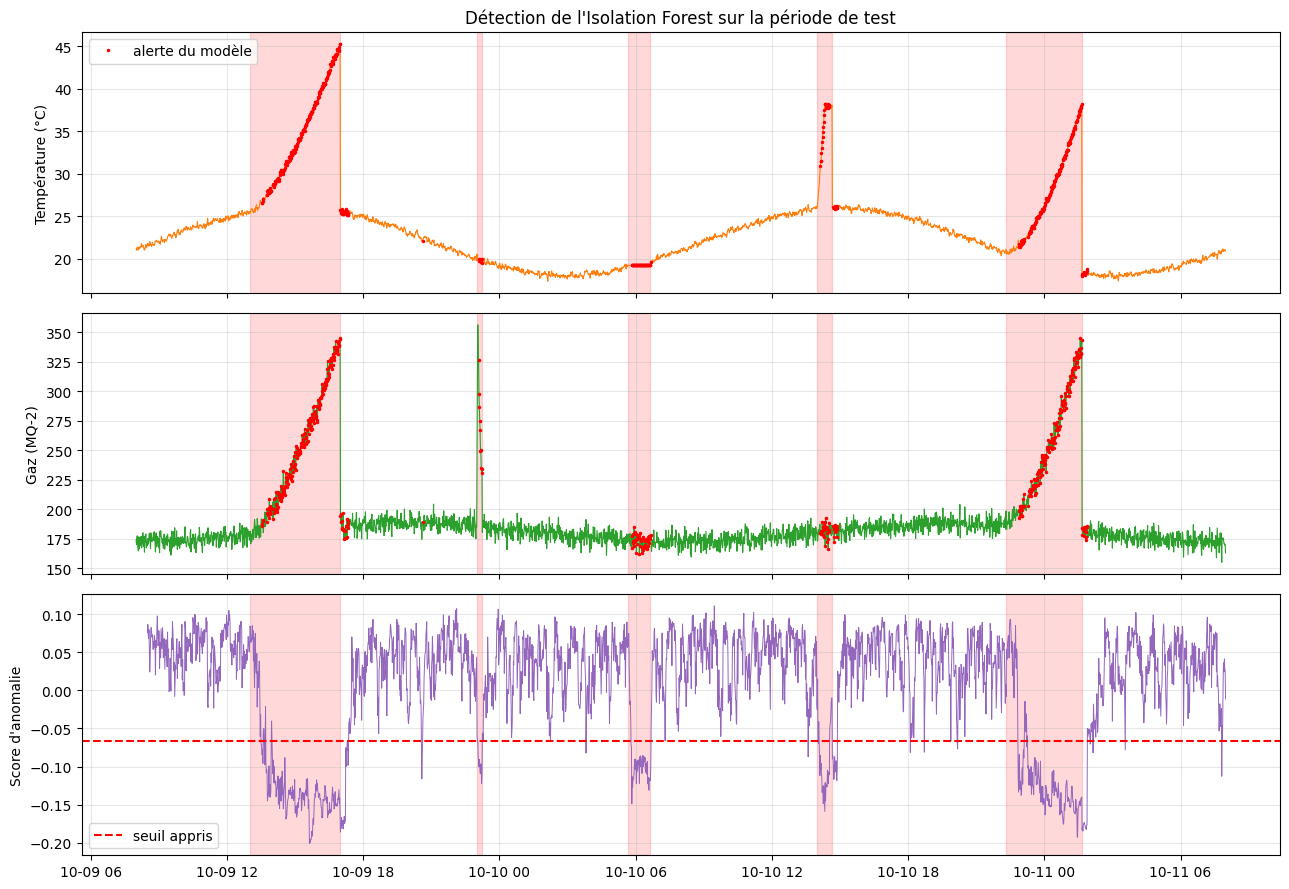

In [7]:
scores_test, alerts_test = detect(bundle, test)
print("Nombre de mesures en alerte sur le test :", int(alerts_test.sum()))
viz.plot_detection(test, scores_test, alerts_test, bundle.threshold);

## Étape 6 — Évaluation

On évalue à **deux niveaux** :

1. **Au niveau des mesures** : précision / rappel / F1 (chaque minute compte comme un exemple) ;
2. **Au niveau des événements** (plus parlant) : chaque panne est-elle détectée ? Avec quel **délai** ? Et surtout : pour les dérives lentes, l'alerte arrive-t-elle **avant** un seuil critique classique ?

Pour comparer, on calcule la date à laquelle un seuil fixe (`température > 38 °C`) aurait déclenché. **Ce seuil sert uniquement de point de comparaison** pour mesurer notre avance — il n'est pas utilisé par le modèle.

In [8]:
pd.Series(point_metrics(y_test, alerts_test.astype(int))).round(3).to_frame("Isolation Forest")

,Isolation Forest
precision,0.897
recall,0.787
f1,0.839
tp,437.000
fp,50.000
fn,118.000
tn,2245.000


In [9]:
report = event_report(test, alerts_test, cfg.evaluation.critical_temperature)
report

,event,start,duration_min,detected,detection_delay_min,lead_over_fixed_threshold_min
0,slow_drift,2026-10-09 13:00:00,240,True,32.0,139.0
1,gas_spike,2026-10-09 23:00:00,15,True,5.0,NaN
2,frozen_sensor,2026-10-10 05:40:00,60,True,10.0,NaN
3,overheating,2026-10-10 14:00:00,40,True,8.0,12.0
4,slow_drift,2026-10-10 22:20:00,200,True,33.0,166.0


In [10]:
fa = false_alarm_breakdown(y_test, alerts_test, tail_window=2 * fc.window_long)
print(f"Fausses alertes : {fa['false_alarms']} sur {fa['normal_samples']} mesures normales "
      f"({fa['false_alarms'] / fa['normal_samples']:.2%})")
print(f"Événements détectés : {int(report['detected'].sum())}/{len(report)}")
print(f"  dont effet de queue juste après une panne : {fa['tail_effect']}")
print(f"  dont fausses alertes « spontanées »        : {fa['spontaneous']}")

Fausses alertes : 50 sur 2295 mesures normales (2.18%)
Événements détectés : 5/5
  dont effet de queue juste après une panne : 49
  dont fausses alertes « spontanées »        : 1


**Comment lire ces résultats ?**
- **Délai de détection** : minutes écoulées entre le début réel de la panne et la première alerte (plus c'est petit, mieux c'est).
- **Avance sur seuil fixe** : pour les dérives lentes, combien de minutes *avant* le dépassement de 38 °C le modèle a prévenu. C'est la **valeur ajoutée** de la maintenance prédictive face à un simple `if`.
- Une partie des « fausses alertes » est un **effet de queue** : juste après la fin d'une panne, les fenêtres glissantes contiennent encore des mesures anormales, donc l'alerte persiste quelques minutes. C'est cohérent (le système n'est pas encore « revenu à la normale »), mais à connaître pour la démo.
- Le **rappel au niveau des mesures** est naturellement < 100 % : le début d'une dérive lente ressemble encore au normal, c'est attendu. Ce qui compte, c'est que l'événement soit repéré **tôt**.

### Expérience à faire
Change `threshold_quantile` dans `configs/default.yaml` (ou via la cellule ci-dessous) : `0.001` → moins de fausses alertes mais détection plus tardive ; `0.02` → détection plus précoce mais plus de fausses alertes. C'est le **compromis précision / rappel** à régler pour la vraie démo.

In [11]:
# Expérience : compromis précision / rappel selon le quantile du seuil
rows = {}
for q in (0.001, 0.005, 0.02):
    b = train_detector(train, replace(cfg, model=replace(cfg.model, threshold_quantile=q)))
    _, al = detect(b, test)
    rows[q] = {**point_metrics(y_test, al.astype(int)),
               "délai moyen (min)": event_report(test, al, 38)["detection_delay_min"].mean()}
pd.DataFrame(rows).T[["precision", "recall", "f1", "fp", "délai moyen (min)"]].round(3)

,precision,recall,f1,fp,délai moyen (min)
0.001,0.917,0.701,0.795,35.0,21.6
0.005,0.897,0.787,0.839,50.0,17.6
0.020,0.845,0.823,0.834,84.0,16.2


## Étape 7 — Export et détection temps réel

Le détecteur est sauvegardé avec tout ce qu'il faut pour rejouer la détection à l'identique (modèle, seuil, fenêtres, persistance, version de scikit-learn).
En production : `RealTimeDetector.update(mesure)` est appelé à chaque mesure reçue de l'ESP8266 et renvoie un payload pour `POST /api/v1/alerts` (ou `None`).

Équivalent CLI : `sentinel-pm train` puis `sentinel-pm replay`.

In [12]:
path = save_bundle(bundle, "../models/sentinel_isolation_forest.joblib")
detector = RealTimeDetector(load_bundle(path), device_id=cfg.device_id)

# Rejouons la 1re dérive lente comme si les mesures arrivaient une par une
drift_start = test.index[cfg.simulation.test_events[0].start]
stream = test.loc[drift_start - pd.Timedelta(minutes=60): drift_start + pd.Timedelta(minutes=240)]

first_alert = None
for ts, row in stream.iterrows():
    first_alert = detector.update({"timestamp": ts, **row[["temperature", "humidity", "gas"]]})
    if first_alert:
        break

print("Début réel de la dérive :", drift_start)
print("Payload qui serait envoyé à POST /api/v1/alerts :")
print(json.dumps(first_alert, indent=2, ensure_ascii=False))

Début réel de la dérive : 2026-10-09 13:00:00
Payload qui serait envoyé à POST /api/v1/alerts :
{
  "device_id": "esp8266-01",
  "type": "predictive_anomaly",
  "severity": "warning",
  "score": -0.0775,
  "timestamp": "2026-10-09T13:32:00",
  "measures": {
    "temperature": 26.53,
    "humidity": 53.86,
    "gas": 185.72
  }
}
